<a href="https://colab.research.google.com/github/mejian1/ExopherGeneExpressionProfiling/blob/main/tripleintersectionpromoterscanningandenrichmentanalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install and load the package
if (!require("BiocManager", quietly = TRUE)) install.packages("BiocManager")
BiocManager::install("KEGGREST")
library(KEGGREST)

# 1. Get the list of all C. elegans pathways
cel_pathways <- keggList("pathway", "cel")

# 2. Get the link between pathways and genes
# This returns a named character vector: names are genes, values are pathways
pathway_gene_links <- keggLink("pathway", "cel")

# 3. Convert to a clean data frame
data <- data.frame(
  Gene_ID = names(pathway_gene_links),
  Pathway_ID = as.character(pathway_gene_links),
  stringsAsFactors = FALSE
)

# Optional: Add pathway names by merging with the cel_pathways list
data$Pathway_Name <- cel_pathways[data$Pathway_ID]
write.csv(data, "cel_kegg_pathways_genes.csv", row.names = FALSE)

SyntaxError: invalid syntax (2534229802.py, line 2)

In [4]:
import pandas as pd

# Load the CSV file into a data frame
df = pd.read_csv('/content/cel_kegg_pathways_genes.csv')

# Display the first few rows of the data frame
df.head()

,Gene_ID,Pathway_ID,Pathway_Name
0,cel:CELE_C01B4.6,path:cel00010,NaN
1,cel:CELE_C04C3.3,path:cel00010,NaN
2,cel:CELE_C30H6.7,path:cel00010,NaN
3,cel:CELE_C36A4.9,path:cel00010,NaN
4,cel:CELE_C50D2.7,path:cel00010,NaN


In [5]:
# Display summary information about the DataFrame
print(df.info())

# Display a random sample of 5 rows to see a broader range of data
display(df.sample(5))

# Check specific counts for Pathway_Name to see if the merge worked for some rows
print(f"\nUnique Pathway Names found: {df['Pathway_Name'].nunique()}")
print(f"Rows with valid Pathway Name: {df['Pathway_Name'].notna().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7704 entries, 0 to 7703
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Gene_ID       7704 non-null   object 
 1   Pathway_ID    7704 non-null   object 
 2   Pathway_Name  0 non-null      float64
dtypes: float64(1), object(2)
memory usage: 180.7+ KB
None


,Gene_ID,Pathway_ID,Pathway_Name
3617,cel:CELE_T27E9.2,path:cel01100,NaN
115,cel:CELE_Y39G8B.1,path:cel00040,NaN
5246,cel:CELE_Y111B2A.22,path:cel03082,NaN
3082,cel:CELE_C55B7.4,path:cel01100,NaN
159,cel:CELE_F35H8.6,path:cel00053,NaN



Unique Pathway Names found: 0
Rows with valid Pathway Name: 0


In [6]:
# Read the list of genes from the text file
with open('/content/tripleIntersectionGenes.txt', 'r') as f:
    gene_list = [line.strip() for line in f if line.strip()]

print(f"Loaded {len(gene_list)} genes from the list.")
print(f"First few genes: {gene_list[:5]}")

Loaded 20 genes from the list.
First few genes: ['Gene_name', 'F26A3.4', 'ceh-6', 'dmd-5', 'arrd-11']


In [7]:
output_file = 'extracted_promoters.fa'
found_count = 0

# Open the output file for writing
with open(output_file, 'w') as out_f:
    # Open the FASTA file for reading
    with open('/content/WS279_elegans_promoters.fa', 'r') as fasta_f:
        write_sequence = False

        for line in fasta_f:
            if line.startswith('>'):
                # Check if the header contains any of our target genes
                # The header format usually contains the gene ID. We need to check if our gene ID is present.
                # Assuming standard FASTA headers like ">GeneID ..."
                header_gene_id = line.split()[0][1:] # clear '>' and take the first word

                # More robust check: see if any gene from our list is in the header line
                # Note: Exact matching logic depends on header format.
                # Let's try checking if the specific gene ID appears in the header.
                # We'll use a set for faster lookup if the headers are clean,
                # but since FASTA headers can be complex, let's check membership carefully.

                is_target = False
                for gene in gene_list:
                     if gene in line:
                        is_target = True
                        break

                if is_target:
                    write_sequence = True
                    out_f.write(line)
                    found_count += 1
                else:
                    write_sequence = False
            elif write_sequence:
                out_f.write(line)

print(f"Extracted {found_count} promoter sequences to {output_file}")

Extracted 19 promoter sequences to extracted_promoters.fa


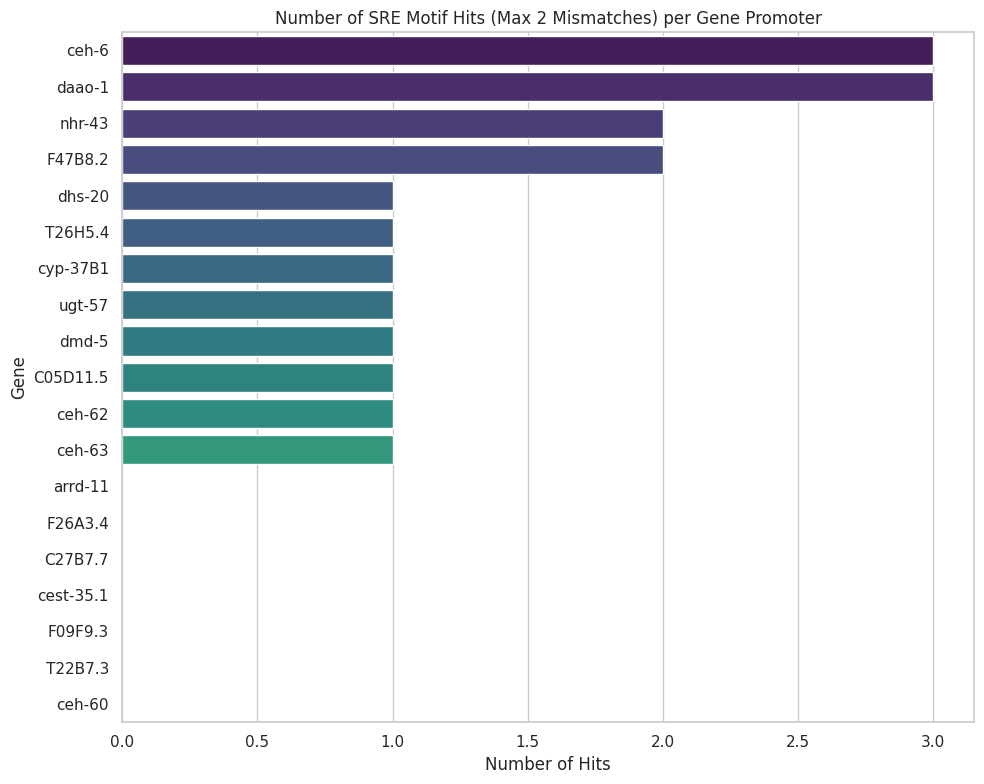

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a cleaner gene name column for plotting
# The current format is 'WBGeneID GeneName', we just want 'GeneName'
summary_df['Gene_Name'] = summary_df['Gene'].apply(lambda x: x.split()[-1] if ' ' in x else x)

# Set plot style
sns.set_theme(style="whitegrid")

# Sort by hits for a better looking plot
plot_data = summary_df.sort_values('Hits_Max2_Mismatch', ascending=False)

# Create the plot
plt.figure(figsize=(10, 8))
# Assign 'y' to 'hue' to fix the palette warning
sns.barplot(data=plot_data, x='Hits_Max2_Mismatch', y='Gene_Name', hue='Gene_Name', palette='viridis', legend=False)

plt.title('Number of SRE Motif Hits (Max 2 Mismatches) per Gene Promoter')
plt.xlabel('Number of Hits')
plt.ylabel('Gene')
plt.tight_layout()
plt.show()

In [9]:
import re

def reverse_complement(seq):
    complement = {'A': 'T', 'C': 'G', 'G': 'C', 'T': 'A', 'N': 'N',
                  'R': 'Y', 'Y': 'R'} # Add degenerate bases if needed for RC
    return "".join(complement.get(base, 'N') for base in reversed(seq))

original_motif = "ATCACCCCAC"
core_motif = "CACCCCAC"
degenerate_motif = "[AG]TC[AG]CCCCAC" # Python regex for RTCRCCCCAC

# Helper to count matches with mismatches
def count_mismatches(seq, motif, max_mismatches):
    count = 0
    motif_len = len(motif)
    for i in range(len(seq) - motif_len + 1):
        subseq = seq[i:i+motif_len]
        diffs = sum(1 for a, b in zip(subseq, motif) if a != b)
        if diffs <= max_mismatches:
            count += 1
    return count

results = []

with open('extracted_promoters.fa', 'r') as f:
    gene_id = ""
    sequence = ""

    def process_sequence(gid, seq):
        # 1. Mismatches (max 2)
        mismatch_fwd = count_mismatches(seq, original_motif, 2)
        mismatch_rev = count_mismatches(seq, reverse_complement(original_motif), 2)

        # 2. Short Core
        core_fwd = seq.count(core_motif)
        core_rev = seq.count(reverse_complement(core_motif))

        # 3. Degenerate (Regex)
        # Note: overlapping matches are tricky with simple regex findall,
        # but for simple counting standard findall is usually sufficient approximation
        # or we can use lookahead for overlapping: (?=(pattern))
        deg_pattern_fwd = f"(?=({degenerate_motif}))"
        deg_pattern_rev = f"(?=({reverse_complement(degenerate_motif).replace('[AG]', '[TC]').replace('[TC]', '[AG]')}))"

        # Fix regex RC: [AG] -> [TC]
        # The RC of [AG] is [TC].
        # RC of RTCRCCCCAC -> GTGGGGYGAY -> GTGGGG[CT]GA[CT]
        deg_rc_str = "GTGGGG[CT]GA[CT]"

        deg_fwd = len(re.findall(deg_pattern_fwd, seq))
        deg_rev = len(re.findall(f"(?=({deg_rc_str}))", seq))

        return (
            gid,
            mismatch_fwd + mismatch_rev,
            core_fwd + core_rev,
            deg_fwd + deg_rev
        )

    for line in f:
        line = line.strip()
        if line.startswith(">"):
            if gene_id:
                results.append(process_sequence(gene_id, sequence))
            gene_id = line[1:]
            sequence = ""
        else:
            sequence += line.upper()

    if gene_id:
        results.append(process_sequence(gene_id, sequence))

# Display Results
summary_df = pd.DataFrame(results, columns=['Gene', 'Hits_Max2_Mismatch', 'Hits_Short_Core', 'Hits_Degenerate'])
display(summary_df)

,Gene,Hits_Max2_Mismatch,Hits_Short_Core,Hits_Degenerate
0,WBGene00000431 ceh-6,3,0,0
1,WBGene00000983 dhs-20,1,0,0
2,WBGene00003633 nhr-43,2,0,0
3,WBGene00007764 C27B7.7,0,0,0
4,WBGene00009142 F26A3.4,0,0,0
5,WBGene00009226 cyp-37B1,1,0,0
6,WBGene00009803 F47B8.2,2,0,0
7,WBGene00011052 arrd-11,0,0,0
8,WBGene00011069 ceh-62,1,0,0
9,WBGene00012069 T26H5.4,1,0,0


In [8]:
def reverse_complement(seq):
    complement = {'A': 'T', 'C': 'G', 'G': 'C', 'T': 'A', 'N': 'N'}
    return "".join(complement.get(base, base) for base in reversed(seq))

# Define the motif to scan for (SRE motif as requested)
motif = "ATCACCCCAC"

# Generate reverse complement to scan both strands
motif_rc = reverse_complement(motif)

print(f"Scanning for motif: {motif} (and RC: {motif_rc})")

results = []

with open('extracted_promoters.fa', 'r') as f:
    gene_id = ""
    sequence = ""
    for line in f:
        line = line.strip()
        if line.startswith(">"):
            if gene_id:
                # Process previous entry
                count_fwd = sequence.count(motif)
                count_rev = sequence.count(motif_rc)
                results.append((gene_id, len(sequence), count_fwd, count_rev, count_fwd + count_rev))

            gene_id = line[1:] # Remove '>'
            sequence = ""
        else:
            sequence += line.upper()

    # Process last entry
    if gene_id:
        count_fwd = sequence.count(motif)
        count_rev = sequence.count(motif_rc)
        results.append((gene_id, len(sequence), count_fwd, count_rev, count_fwd + count_rev))

# Create a DataFrame to display results
import pandas as pd
motif_df = pd.DataFrame(results, columns=['Gene_Header', 'Seq_Length', 'Count_Fwd', 'Count_Rev', 'Total_Hits'])
display(motif_df)

Scanning for motif: ATCACCCCAC (and RC: GTGGGGTGAT)


,Gene_Header,Seq_Length,Count_Fwd,Count_Rev,Total_Hits
0,WBGene00000431 ceh-6,2500,0,0,0
1,WBGene00000983 dhs-20,2500,0,0,0
2,WBGene00003633 nhr-43,2500,0,0,0
3,WBGene00007764 C27B7.7,2500,0,0,0
4,WBGene00009142 F26A3.4,2500,0,0,0
5,WBGene00009226 cyp-37B1,2500,0,0,0
6,WBGene00009803 F47B8.2,2500,0,0,0
7,WBGene00011052 arrd-11,2500,0,0,0
8,WBGene00011069 ceh-62,2500,0,0,0
9,WBGene00012069 T26H5.4,2500,0,0,0
